# Stage 9 — Robustness Analysis

## 1. Objective

The objective of Stage 9 is to evaluate whether model performance remains stable across different random seeds and stratified cross-validation partitions.

A single train/test split or a single cross-validation configuration can produce results that depend partly on the particular partition of the data. Therefore, robustness analysis evaluates the consistency of the model across multiple random seeds.

The main research question is:

> Are the observed classification results stable across different random stratified cross-validation configurations?

---

## 2. Dataset

The experiment uses the UCI Bank Marketing dataset, specifically:

`bank-full.csv`

The target variable is:

`y`

where:

- `0` = customer did not subscribe to a term deposit
- `1` = customer subscribed to a term deposit

The dataset contains 45,211 observations and 17 columns.

---

## 3. Experimental Design

The original dataset is divided into:

- 80% training data
- 20% untouched test data

The split is stratified using:

`random_state = 42`

The test set is not used during robustness cross-validation.

---

## 4. Model

The model evaluated in this stage is Logistic Regression with:

`class_weight = "balanced"`

The model is combined with a leakage-safe preprocessing pipeline containing:

- StandardScaler for numerical features
- OneHotEncoder for categorical features
- Logistic Regression classifier

Preprocessing is fitted independently inside each cross-validation training fold.

---

## 5. Cross-Validation Strategy

The training data is evaluated using:

- Stratified K-Fold Cross-Validation
- 3 folds
- Shuffling enabled

Five different random seeds are evaluated:

- 42
- 7
- 21
- 52
- 100

Therefore:

5 seeds × 3 folds = 15 fold-level evaluations.

---

## 6. Evaluation Metrics

The following metrics are evaluated:

### Accuracy

Measures the overall proportion of correctly classified observations.

### Precision

Measures the proportion of predicted positive observations that are actually positive.

### Recall

Measures the proportion of actual positive observations correctly identified.

### F1 Score

The harmonic mean of precision and recall.

F1 is especially relevant because the dataset contains a substantial class imbalance.

### Balanced Accuracy

Accounts for performance on both classes rather than relying only on overall accuracy.

### PR-AUC

Measures ranking performance with emphasis on the positive/minority class.

### ROC-AUC

Measures the model's ability to distinguish between the two classes across classification thresholds.

---

## 7. Why Robustness Analysis Is Important

The Bank Marketing dataset is imbalanced, with the positive class representing a minority of observations.

Consequently, model performance should not be evaluated using accuracy alone.

Robustness analysis provides additional evidence about whether minority-class performance remains reasonably consistent across different validation partitions.

---

## 8. Research Interpretation

The mean and standard deviation of each metric are calculated across all robustness evaluations.

Results should be reported in the form:

`Mean ± Standard Deviation`

Lower variability indicates greater consistency under the tested validation configurations.

However, low variability does not automatically imply that the model is optimal.

Similarly, a higher mean metric should be interpreted together with the associated variability and the research objective.

---

## 9. Relationship to Earlier Stages

Stage 9 complements the earlier experimental stages.

Stage 4 established baseline model performance.

Stage 5 studied class-imbalance strategies.

Stage 6 investigated hyperparameter optimization.

Stage 7 investigated multi-objective optimization using F1 and PR-AUC.

Stage 8 investigated decision-threshold optimization.

Stage 9 evaluates whether the observed performance is stable across different random validation configurations.

---

## 10. Leakage Prevention

No information from the validation fold is used during preprocessing or model fitting.

For every fold:

Training Fold
→ Fit Preprocessor
→ Transform Training Fold
→ Train Logistic Regression
→ Transform Validation Fold
→ Predict Validation Fold
→ Calculate Metrics

This prevents preprocessing leakage between training and validation data.

---

## 11. Reproducibility

The experiment uses explicitly defined random seeds:

42, 7, 21, 52, and 100.

The same dataset and fixed train/test split are used throughout the experiment.

This makes the experiment reproducible and allows the effect of validation randomness to be examined systematically.

---

## 12. Saved Outputs

The following files are generated:

`../results/metrics/robustness_fold_results.csv`

Contains fold-level results for every seed.

`../results/metrics/robustness_summary.csv`

Contains mean and standard deviation for every metric.

`../results/metrics/robustness_seed_summary.csv`

Contains average performance for each random seed.

---

## 13. Research Question Answered

Stage 9 addresses:

> How sensitive is the model's observed performance to changes in the random cross-validation configuration?

The final conclusions should be based on the actual experimental results rather than assuming that the model is robust beforehand.

---

## 14. Important Limitation

Robustness across five random seeds and three folds provides evidence of stability under the tested configurations, but it does not prove universal robustness.

Additional external datasets or repeated experiments could provide stronger evidence of generalization.

---

## 15. Stage 9 Conclusion

Stage 9 provides a reproducible robustness evaluation of the imbalance-aware Logistic Regression model.

The resulting mean, standard deviation, seed-level performance, and fold-level results will be used later when comparing models and evaluating the reliability of the proposed explainable HPO framework.

In [1]:
# ============================================================
# CELL 2 — IMPORT LIBRARIES
# ============================================================

import os
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import plotly.express as px
import plotly.graph_objects as go

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    balanced_accuracy_score
)

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# ============================================================
# CELL 3 — LOAD DATASET
# ============================================================

data_path = "../data/raw/bank-full.csv"

df = pd.read_csv(data_path)

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)

display(df.head())

Dataset loaded successfully!
Dataset shape: (45211, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,18,student,single,primary,no,1944,no,no,telephone,10,aug,122,3,-1,0,unknown,no
1,18,student,single,unknown,no,108,no,no,cellular,10,aug,167,1,-1,0,unknown,yes
2,18,student,single,primary,no,608,no,no,cellular,12,aug,267,1,-1,0,unknown,yes
3,18,student,single,unknown,no,35,no,no,telephone,21,aug,104,2,-1,0,unknown,no
4,18,student,single,secondary,no,5,no,no,cellular,24,aug,143,2,-1,0,unknown,no


In [3]:
# ============================================================
# CELL 4 — SEPARATE FEATURES AND TARGET
# ============================================================

X = df.drop(columns=["y"])
y = df["y"].map({
    "no": 0,
    "yes": 1
})

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

print("\nTarget distribution:")
display(y.value_counts())

print("\nTarget proportions:")
display(
    y.value_counts(normalize=True).round(4)
)

Feature shape: (45211, 16)
Target shape: (45211,)

Target distribution:


y
0    39922
1     5289
Name: count, dtype: int64


Target proportions:


y
0    0.883
1    0.117
Name: proportion, dtype: float64

In [4]:
# ============================================================
# CELL 5 — IDENTIFY NUMERIC AND CATEGORICAL FEATURES
# ============================================================

numeric_columns = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_columns = X.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numeric features:")
print(numeric_columns)

print("\nCategorical features:")
print(categorical_columns)

print("\nNumber of numeric features:", len(numeric_columns))
print("Number of categorical features:", len(categorical_columns))

Numeric features:
['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']

Categorical features:
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']

Number of numeric features: 7
Number of categorical features: 9


In [5]:
# ============================================================
# CELL 6 — CREATE FIXED TRAIN / TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

print("\nTraining target distribution:")
display(y_train.value_counts())

print("\nTesting target distribution:")
display(y_test.value_counts())

Training samples: 36168
Testing samples: 9043

Training target distribution:


y
0    31937
1     4231
Name: count, dtype: int64


Testing target distribution:


y
0    7985
1    1058
Name: count, dtype: int64

In [6]:
# ============================================================
# CELL 7 — CREATE LEAKAGE-SAFE PREPROCESSOR
# ============================================================

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            StandardScaler(),
            numeric_columns
        ),
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_columns
        )
    ]
)

print("Preprocessor created successfully.")

Preprocessor created successfully.


In [7]:
# ============================================================
# CELL 8 — DEFINE RANDOM SEEDS
# ============================================================

random_seeds = [42, 7, 21, 52, 100]

print("Robustness random seeds:")
print(random_seeds)

print("Number of seeds:", len(random_seeds))

Robustness random seeds:
[42, 7, 21, 52, 100]
Number of seeds: 5


In [8]:
# ============================================================
# CELL 9 — DEFINE CROSS-VALIDATION EVALUATION FUNCTION
# ============================================================

def evaluate_model_robustness(
    X_data,
    y_data,
    random_seed,
    n_splits=3
):
    
    cv = StratifiedKFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=random_seed
    )
    
    fold_results = []
    
    for fold_number, (train_idx, valid_idx) in enumerate(
        cv.split(X_data, y_data),
        start=1
    ):
        
        X_fold_train = X_data.iloc[train_idx]
        X_fold_valid = X_data.iloc[valid_idx]
        
        y_fold_train = y_data.iloc[train_idx]
        y_fold_valid = y_data.iloc[valid_idx]
        
        model = Pipeline(
            steps=[
                (
                    "preprocessor",
                    preprocessor
                ),
                (
                    "classifier",
                    LogisticRegression(
                        max_iter=1000,
                        class_weight="balanced",
                        random_state=42
                    )
                )
            ]
        )
        
        model.fit(
            X_fold_train,
            y_fold_train
        )
        
        probabilities = model.predict_proba(
            X_fold_valid
        )[:, 1]
        
        predictions = (
            probabilities >= 0.50
        ).astype(int)
        
        fold_results.append({
            "Random_Seed": random_seed,
            "Fold": fold_number,
            "Accuracy": accuracy_score(
                y_fold_valid,
                predictions
            ),
            "Precision": precision_score(
                y_fold_valid,
                predictions,
                zero_division=0
            ),
            "Recall": recall_score(
                y_fold_valid,
                predictions,
                zero_division=0
            ),
            "F1": f1_score(
                y_fold_valid,
                predictions,
                zero_division=0
            ),
            "Balanced_Accuracy": balanced_accuracy_score(
                y_fold_valid,
                predictions
            ),
            "PR_AUC": average_precision_score(
                y_fold_valid,
                probabilities
            ),
            "ROC_AUC": roc_auc_score(
                y_fold_valid,
                probabilities
            )
        })
    
    return pd.DataFrame(fold_results)


print("Robustness evaluation function created successfully.")

Robustness evaluation function created successfully.


In [9]:
# ============================================================
# CELL 10 — RUN ROBUSTNESS EXPERIMENT
# ============================================================

all_robustness_results = []

for seed in random_seeds:
    
    print(f"Running seed: {seed}")
    
    seed_results = evaluate_model_robustness(
        X_train,
        y_train,
        random_seed=seed,
        n_splits=3
    )
    
    all_robustness_results.append(
        seed_results
    )

robustness_results = pd.concat(
    all_robustness_results,
    ignore_index=True
)

print("\nRobustness experiment completed.")

print(
    "\nTotal evaluation rows:",
    len(robustness_results)
)

display(
    robustness_results.round(4)
)

Running seed: 42
Running seed: 7
Running seed: 21
Running seed: 52
Running seed: 100

Robustness experiment completed.

Total evaluation rows: 15


,Random_Seed,Fold,Accuracy,Precision,Recall,F1,Balanced_Accuracy,PR_AUC,ROC_AUC
0,42,1,0.8409,0.4102,0.8227,0.5474,0.8330,0.5304,0.9066
1,42,2,0.8453,0.4167,0.8071,0.5496,0.8287,0.5522,0.9071
2,42,3,0.8407,0.4094,0.8150,0.5450,0.8296,0.5491,0.9095
3,7,1,0.8430,0.4117,0.7986,0.5433,0.8237,0.5373,0.9020
4,7,2,0.8397,0.4083,0.8262,0.5466,0.8338,0.5385,0.9103
5,7,3,0.8430,0.4132,0.8136,0.5481,0.8302,0.5566,0.9110
6,21,1,0.8412,0.4104,0.8206,0.5472,0.8322,0.5478,0.9097
7,21,2,0.8439,0.4139,0.8050,0.5467,0.8270,0.5406,0.9059
8,21,3,0.8405,0.4091,0.8164,0.5451,0.8301,0.5432,0.9080
9,52,1,0.8490,0.4247,0.8206,0.5597,0.8367,0.5597,0.9117


In [10]:
# ============================================================
# CELL 11 — VALIDATE ROBUSTNESS EXPERIMENT
# ============================================================

print("=" * 80)
print("ROBUSTNESS EXPERIMENT VALIDATION")
print("=" * 80)

print(
    "\nExpected evaluation rows:",
    len(random_seeds) * 3
)

print(
    "Actual evaluation rows:",
    len(robustness_results)
)

assert len(
    robustness_results
) == len(random_seeds) * 3

assert set(
    robustness_results["Random_Seed"]
) == set(random_seeds)

assert robustness_results[
    [
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "Balanced_Accuracy",
        "PR_AUC",
        "ROC_AUC"
    ]
].notna().all().all()

assert (
    robustness_results[
        [
            "Accuracy",
            "Precision",
            "Recall",
            "F1",
            "Balanced_Accuracy",
            "PR_AUC",
            "ROC_AUC"
        ]
    ] >= 0
).all().all()

assert (
    robustness_results[
        [
            "Accuracy",
            "Precision",
            "Recall",
            "F1",
            "Balanced_Accuracy",
            "PR_AUC",
            "ROC_AUC"
        ]
    ] <= 1
).all().all()

print("\n✓ Correct number of seed/fold evaluations.")
print("✓ All requested seeds are present.")
print("✓ No missing metric values.")
print("✓ Metrics are within valid ranges.")

ROBUSTNESS EXPERIMENT VALIDATION

Expected evaluation rows: 15
Actual evaluation rows: 15

✓ Correct number of seed/fold evaluations.
✓ All requested seeds are present.
✓ No missing metric values.
✓ Metrics are within valid ranges.


In [11]:
# ============================================================
# CELL 12 — ROBUSTNESS SUMMARY
# ============================================================

metric_columns = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1",
    "Balanced_Accuracy",
    "PR_AUC",
    "ROC_AUC"
]

robustness_summary = (
    robustness_results[metric_columns]
    .agg(["mean", "std"])
    .T
    .reset_index()
)

robustness_summary.columns = [
    "Metric",
    "Mean",
    "Std"
]

print("=" * 80)
print("ROBUSTNESS SUMMARY — MEAN ± STANDARD DEVIATION")
print("=" * 80)

display(
    robustness_summary.round(4)
)

ROBUSTNESS SUMMARY — MEAN ± STANDARD DEVIATION


,Metric,Mean,Std
0,Accuracy,0.8420,0.0030
1,Precision,0.4114,0.0055
2,Recall,0.8137,0.0103
3,F1,0.5464,0.0059
4,Balanced_Accuracy,0.8297,0.0049
5,PR_AUC,0.5439,0.0110
6,ROC_AUC,0.9078,0.0034


In [12]:
# ============================================================
# CELL 13 — PERFORMANCE BY RANDOM SEED
# ============================================================

seed_summary = (
    robustness_results
    .groupby("Random_Seed")[metric_columns]
    .mean()
    .reset_index()
)

print("=" * 80)
print("MEAN PERFORMANCE BY RANDOM SEED")
print("=" * 80)

display(
    seed_summary.round(4)
)

MEAN PERFORMANCE BY RANDOM SEED


,Random_Seed,Accuracy,Precision,Recall,F1,Balanced_Accuracy,PR_AUC,ROC_AUC
0,7,0.8419,0.4111,0.8128,0.5460,0.8293,0.5441,0.9078
1,21,0.8418,0.4112,0.8140,0.5463,0.8298,0.5439,0.9079
2,42,0.8423,0.4121,0.8149,0.5474,0.8304,0.5439,0.9077
3,52,0.8420,0.4114,0.8119,0.5460,0.8289,0.5435,0.9076
4,100,0.8418,0.4112,0.8147,0.5465,0.8301,0.5440,0.9081


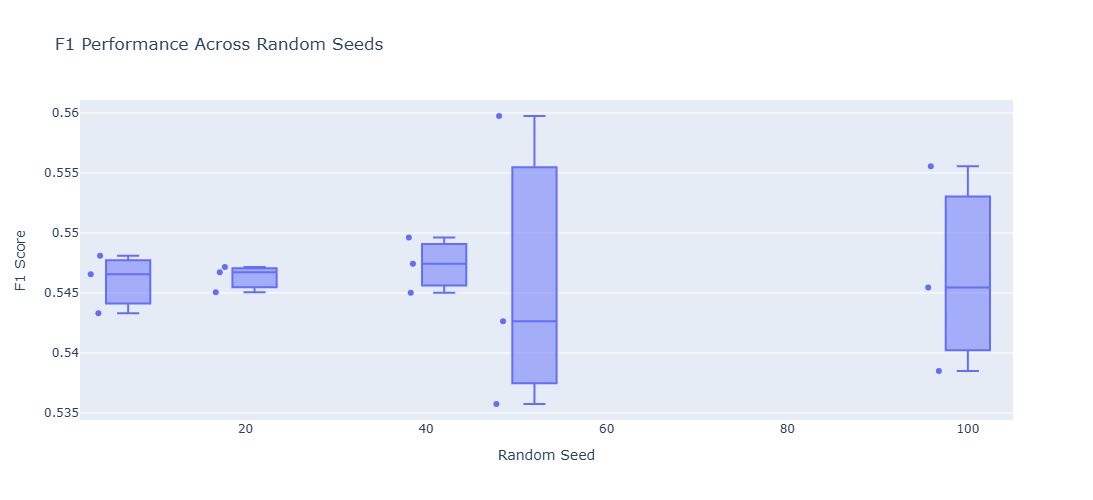

In [13]:
# ============================================================
# CELL 14 — F1 PERFORMANCE ACROSS RANDOM SEEDS
# ============================================================

fig = px.box(
    robustness_results,
    x="Random_Seed",
    y="F1",
    points="all",
    title="F1 Performance Across Random Seeds",
    labels={
        "Random_Seed": "Random Seed",
        "F1": "F1 Score"
    }
)

fig.update_layout(
    width=850,
    height=500
)

fig.show()

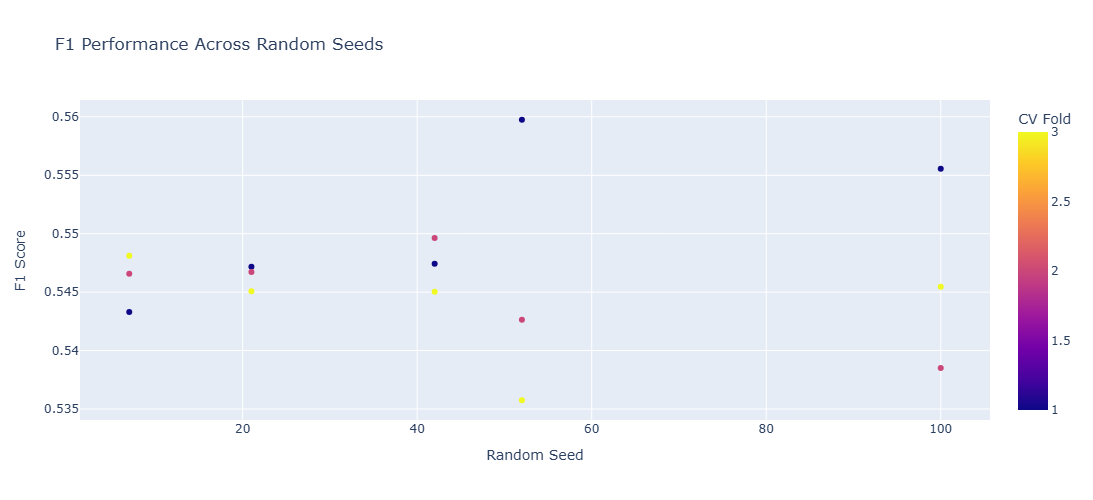

In [14]:
# ============================================================
# CELL 14 — F1 PERFORMANCE ACROSS RANDOM SEEDS
# ============================================================

fig = px.scatter(
    robustness_results,
    x="Random_Seed",
    y="F1",
    color="Fold",
    title="F1 Performance Across Random Seeds",
    labels={
        "Random_Seed": "Random Seed",
        "F1": "F1 Score",
        "Fold": "CV Fold"
    },
    hover_data=metric_columns
)

fig.update_layout(
    width=850,
    height=500
)

fig.show()

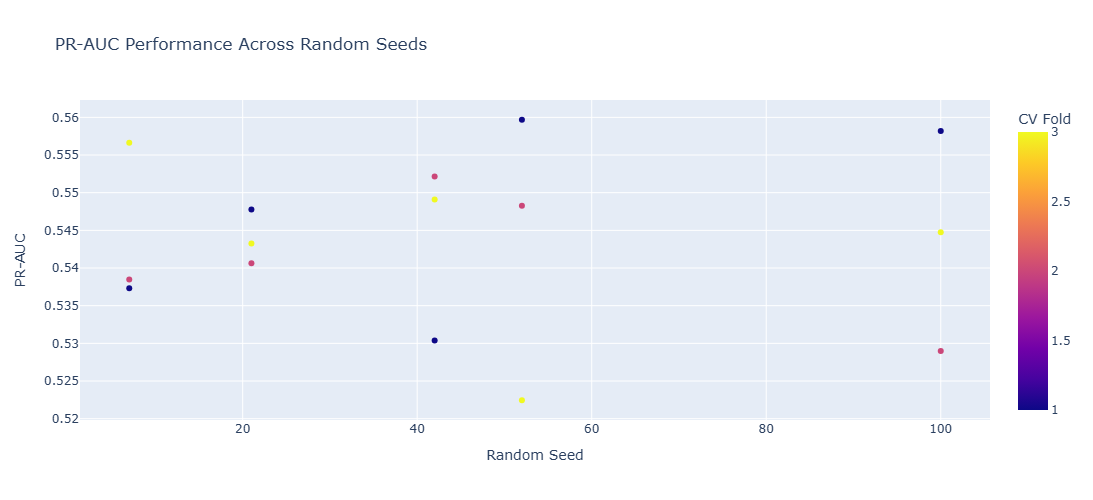

In [15]:
# ============================================================
# CELL 15 — PR-AUC PERFORMANCE ACROSS RANDOM SEEDS
# ============================================================

fig = px.scatter(
    robustness_results,
    x="Random_Seed",
    y="PR_AUC",
    color="Fold",
    title="PR-AUC Performance Across Random Seeds",
    labels={
        "Random_Seed": "Random Seed",
        "PR_AUC": "PR-AUC",
        "Fold": "CV Fold"
    },
    hover_data=[
        "F1",
        "Recall",
        "Precision",
        "Balanced_Accuracy",
        "ROC_AUC"
    ]
)

fig.update_layout(
    width=850,
    height=500
)

fig.show()

In [16]:
# ============================================================
# CELL 16 — METRIC VARIABILITY
# ============================================================

metric_variability = (
    robustness_results[metric_columns]
    .std()
    .reset_index()
)

metric_variability.columns = [
    "Metric",
    "Standard_Deviation"
]

metric_variability = metric_variability.sort_values(
    "Standard_Deviation",
    ascending=False
)

print("=" * 80)
print("METRIC VARIABILITY")
print("=" * 80)

display(
    metric_variability.round(5)
)

METRIC VARIABILITY


,Metric,Standard_Deviation
5,PR_AUC,0.01100
2,Recall,0.01027
3,F1,0.00586
1,Precision,0.00546
4,Balanced_Accuracy,0.00491
6,ROC_AUC,0.00342
0,Accuracy,0.00298


In [17]:
# ============================================================
# CELL 17 — RELATIVE VARIABILITY
# ============================================================

relative_variability = robustness_summary.copy()

relative_variability["Coefficient_of_Variation"] = (
    relative_variability["Std"]
    /
    relative_variability["Mean"]
)

print("=" * 80)
print("RELATIVE METRIC VARIABILITY")
print("=" * 80)

display(
    relative_variability.round(5)
)

RELATIVE METRIC VARIABILITY


,Metric,Mean,Std,Coefficient_of_Variation
0,Accuracy,0.84198,0.00298,0.00354
1,Precision,0.41138,0.00546,0.01327
2,Recall,0.81366,0.01027,0.01263
3,F1,0.54644,0.00586,0.01073
4,Balanced_Accuracy,0.82970,0.00491,0.00592
5,PR_AUC,0.54387,0.01100,0.02023
6,ROC_AUC,0.90781,0.00342,0.00376


In [18]:
# ============================================================
# CELL 18 — SAVE FOLD-LEVEL ROBUSTNESS RESULTS
# ============================================================

os.makedirs(
    "../results/metrics",
    exist_ok=True
)

fold_results_path = (
    "../results/metrics/"
    "robustness_fold_results.csv"
)

robustness_results.to_csv(
    fold_results_path,
    index=False
)

print(
    "Fold-level robustness results saved:"
)

print(fold_results_path)

Fold-level robustness results saved:
../results/metrics/robustness_fold_results.csv


In [19]:
# ============================================================
# CELL 19 — SAVE ROBUSTNESS SUMMARY
# ============================================================

summary_path = (
    "../results/metrics/"
    "robustness_summary.csv"
)

robustness_summary.to_csv(
    summary_path,
    index=False
)

print(
    "Robustness summary saved:"
)

print(summary_path)

display(
    robustness_summary.round(4)
)

Robustness summary saved:
../results/metrics/robustness_summary.csv


,Metric,Mean,Std
0,Accuracy,0.8420,0.0030
1,Precision,0.4114,0.0055
2,Recall,0.8137,0.0103
3,F1,0.5464,0.0059
4,Balanced_Accuracy,0.8297,0.0049
5,PR_AUC,0.5439,0.0110
6,ROC_AUC,0.9078,0.0034


In [20]:
# ============================================================
# CELL 20 — SAVE SEED-LEVEL SUMMARY
# ============================================================

seed_summary_path = (
    "../results/metrics/"
    "robustness_seed_summary.csv"
)

seed_summary.to_csv(
    seed_summary_path,
    index=False
)

print(
    "Seed-level summary saved:"
)

print(seed_summary_path)

display(
    seed_summary.round(4)
)

Seed-level summary saved:
../results/metrics/robustness_seed_summary.csv


,Random_Seed,Accuracy,Precision,Recall,F1,Balanced_Accuracy,PR_AUC,ROC_AUC
0,7,0.8419,0.4111,0.8128,0.5460,0.8293,0.5441,0.9078
1,21,0.8418,0.4112,0.8140,0.5463,0.8298,0.5439,0.9079
2,42,0.8423,0.4121,0.8149,0.5474,0.8304,0.5439,0.9077
3,52,0.8420,0.4114,0.8119,0.5460,0.8289,0.5435,0.9076
4,100,0.8418,0.4112,0.8147,0.5465,0.8301,0.5440,0.9081


In [21]:
# ============================================================
# CELL 21 — FINAL STAGE 9 VALIDATION
# ============================================================

print("=" * 80)
print("STAGE 9 FINAL VALIDATION")
print("=" * 80)

assert len(random_seeds) == 5

assert len(
    robustness_results
) == 15

assert len(
    robustness_summary
) == 7

assert os.path.exists(
    "../results/metrics/"
    "robustness_fold_results.csv"
)

assert os.path.exists(
    "../results/metrics/"
    "robustness_summary.csv"
)

assert os.path.exists(
    "../results/metrics/"
    "robustness_seed_summary.csv"
)

assert (
    robustness_results["Random_Seed"]
    .nunique()
    == 5
)

assert (
    robustness_results["Fold"]
    .nunique()
    == 3
)

print("✓ Five random seeds evaluated.")
print("✓ Three stratified folds per seed.")
print("✓ 15 total fold evaluations completed.")
print("✓ Seven evaluation metrics calculated.")
print("✓ Robustness results saved.")
print("✓ Robustness summary saved.")
print("✓ Seed-level summary saved.")

print("\nSTAGE 9 COMPLETED SUCCESSFULLY.")

STAGE 9 FINAL VALIDATION
✓ Five random seeds evaluated.
✓ Three stratified folds per seed.
✓ 15 total fold evaluations completed.
✓ Seven evaluation metrics calculated.
✓ Robustness results saved.
✓ Robustness summary saved.
✓ Seed-level summary saved.

STAGE 9 COMPLETED SUCCESSFULLY.
